In [1]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [3]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:06<00:00, 26.8MB/s]


In [4]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [5]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [6]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

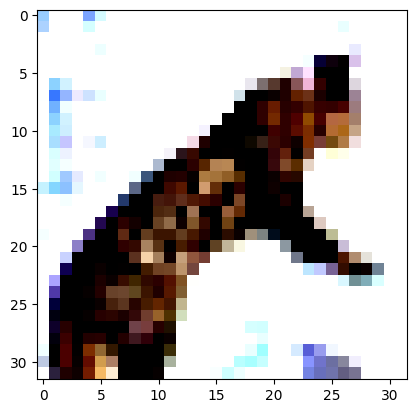

In [7]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [8]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [9]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [10]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [11]:
class Trainer:
    def __init__(self, config, model_ctor=BasicCNN, transform=None):
        self.config = config
        self.model_ctor = model_ctor
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.model = self.model_ctor().to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'test_loss': None,
            'test_acc': None,
        }

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)

            print(
                f"Epoch {epoch + 1} / {self.config['num_epochs']}: "
                f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
                f"train_acc={train_acc:.2f}%, val_acc={val_acc:.2f}%"
            )

        test_loss, test_acc = self.test_step()
        self.history['test_loss'] = test_loss
        self.history['test_acc'] = test_acc
        print(f"Test: loss={test_loss:.4f}, acc={test_acc:.2f}%")

        return self.history

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        return self.eval_step(self.val_loader)

    def test_step(self):
        return self.eval_step(self.test_loader)

    def eval_step(self, loader):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc

In [12]:
cnn_trainer = Trainer(config, model_ctor=BasicCNN, transform=transform)

In [13]:
history_cnn = cnn_trainer.run()

100%|██████████| 79/79 [00:03<00:00, 25.22it/s]


Epoch 1 / 10: train_loss=2.3055, val_loss=2.3031, train_acc=9.85%, val_acc=9.79%


100%|██████████| 79/79 [00:03<00:00, 24.48it/s]


Epoch 2 / 10: train_loss=2.3032, val_loss=2.3031, train_acc=10.08%, val_acc=10.30%


100%|██████████| 79/79 [00:02<00:00, 29.69it/s]


...

Epoch 9 / 10: train_loss=2.3027, val_loss=2.3028, train_acc=10.17%, val_acc=9.33%


100%|██████████| 79/79 [00:02<00:00, 27.01it/s]


Epoch 10 / 10: train_loss=2.3027, val_loss=2.3029, train_acc=9.95%, val_acc=9.33%


100%|██████████| 79/79 [00:03<00:00, 25.94it/s]

Test: loss=2.3026, acc=10.00%


# ResNet-18

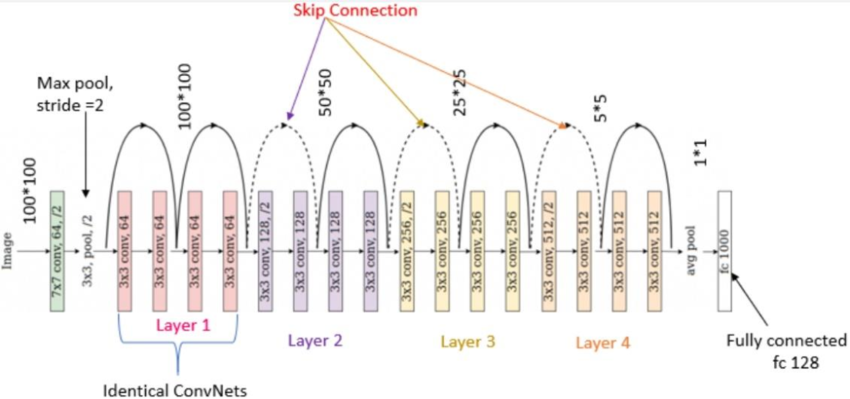

In [14]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(identity)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Сделать 4 блока
        self.layer1 = self.make_layer(out_channels=64, blocks=2, stride=1)
        self.layer2 = self.make_layer(out_channels=128, blocks=2, stride=2)
        self.layer3 = self.make_layer(out_channels=256, blocks=2, stride=2)
        self.layer4 = self.make_layer(out_channels=512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = [ResNetBlock(self.in_channels, out_channels, stride=stride, downsample=downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResNetBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.max_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [15]:
resnet_trainer = Trainer(config, model_ctor=ResNet18, transform=transform)
history_resnet = resnet_trainer.run()

epochs = list(range(1, config['num_epochs'] + 1))

def _best_epoch(history, key):
    values = history[key]
    best_idx = max(range(len(values)), key=lambda i: values[i])
    return best_idx + 1, values[best_idx]

best_cnn_epoch, best_cnn_val_acc = _best_epoch(history_cnn, 'val_acc')
best_resnet_epoch, best_resnet_val_acc = _best_epoch(history_resnet, 'val_acc')


100%|██████████| 79/79 [00:03<00:00, 24.22it/s]


Epoch 1 / 10: train_loss=1.8498, val_loss=1.4525, train_acc=34.64%, val_acc=46.05%


100%|██████████| 79/79 [00:03<00:00, 21.39it/s]


Epoch 2 / 10: train_loss=1.3140, val_loss=1.3442, train_acc=52.58%, val_acc=51.92%


100%|██████████| 79/79 [00:03<00:00, 23.67it/s]


...

Epoch 9 / 10: train_loss=0.2654, val_loss=0.8324, train_acc=90.77%, val_acc=75.75%


100%|██████████| 79/79 [00:03<00:00, 24.83it/s]


Epoch 10 / 10: train_loss=0.1892, val_loss=0.9551, train_acc=93.42%, val_acc=75.35%


100%|██████████| 79/79 [00:04<00:00, 19.53it/s]

Test: loss=1.0090, acc=74.59%


Сравнение (CNN vs ResNet18) для loss/accuracy

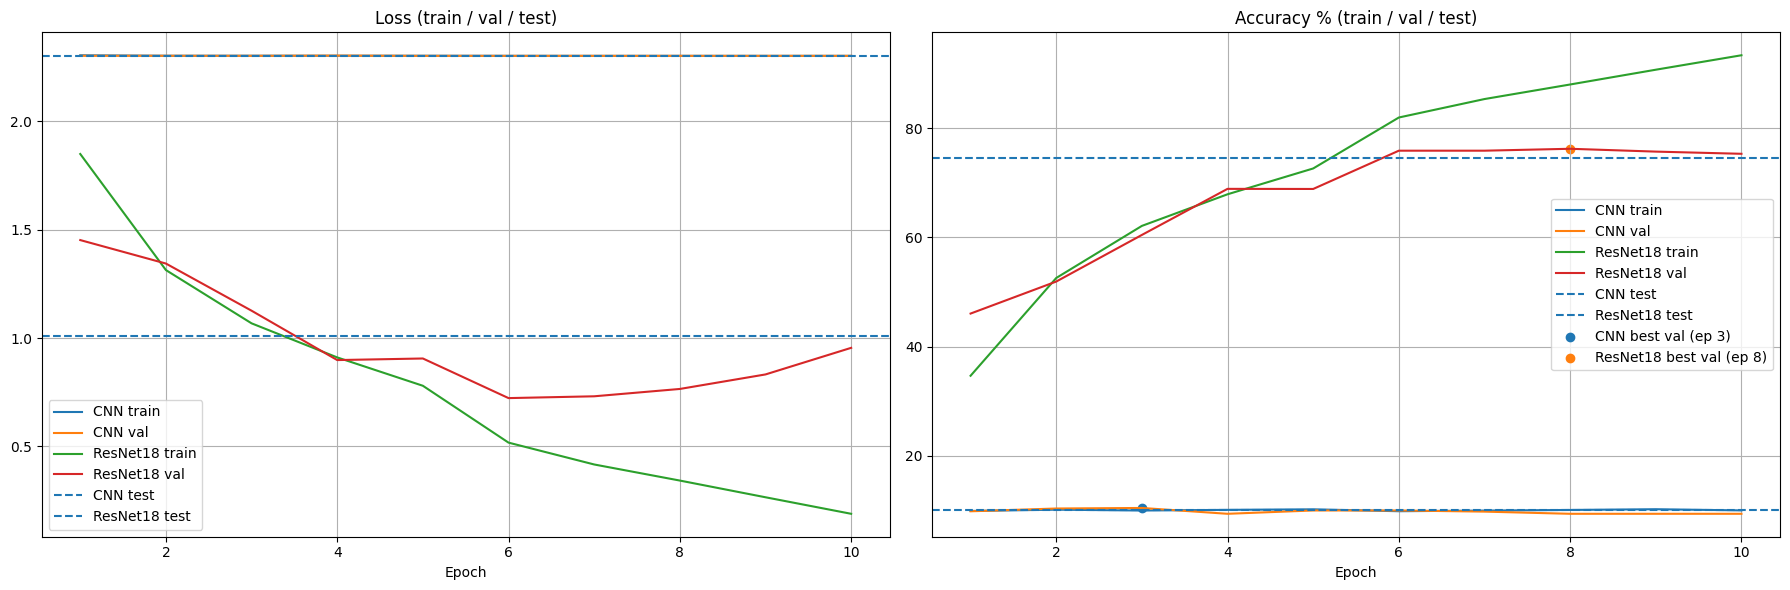

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(epochs, history_cnn['train_loss'], label='CNN train')
axes[0].plot(epochs, history_cnn['val_loss'], label='CNN val')
axes[0].plot(epochs, history_resnet['train_loss'], label='ResNet18 train')
axes[0].plot(epochs, history_resnet['val_loss'], label='ResNet18 val')
axes[0].axhline(history_cnn['test_loss'], linestyle='--', linewidth=1.5, label='CNN test')
axes[0].axhline(history_resnet['test_loss'], linestyle='--', linewidth=1.5, label='ResNet18 test')
axes[0].set_title('Loss (train / val / test)')
axes[0].set_xlabel('Epoch')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(epochs, history_cnn['train_acc'], label='CNN train')
axes[1].plot(epochs, history_cnn['val_acc'], label='CNN val')
axes[1].plot(epochs, history_resnet['train_acc'], label='ResNet18 train')
axes[1].plot(epochs, history_resnet['val_acc'], label='ResNet18 val')
axes[1].axhline(history_cnn['test_acc'], linestyle='--', linewidth=1.5, label='CNN test')
axes[1].axhline(history_resnet['test_acc'], linestyle='--', linewidth=1.5, label='ResNet18 test')
axes[1].scatter([best_cnn_epoch], [best_cnn_val_acc], label=f'CNN best val (ep {best_cnn_epoch})', marker='o')
axes[1].scatter([best_resnet_epoch], [best_resnet_val_acc], label=f'ResNet18 best val (ep {best_resnet_epoch})', marker='o')
axes[1].set_title('Accuracy % (train / val / test)')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

Расширенные графики: отдельно по моделям (train/val + test линия)

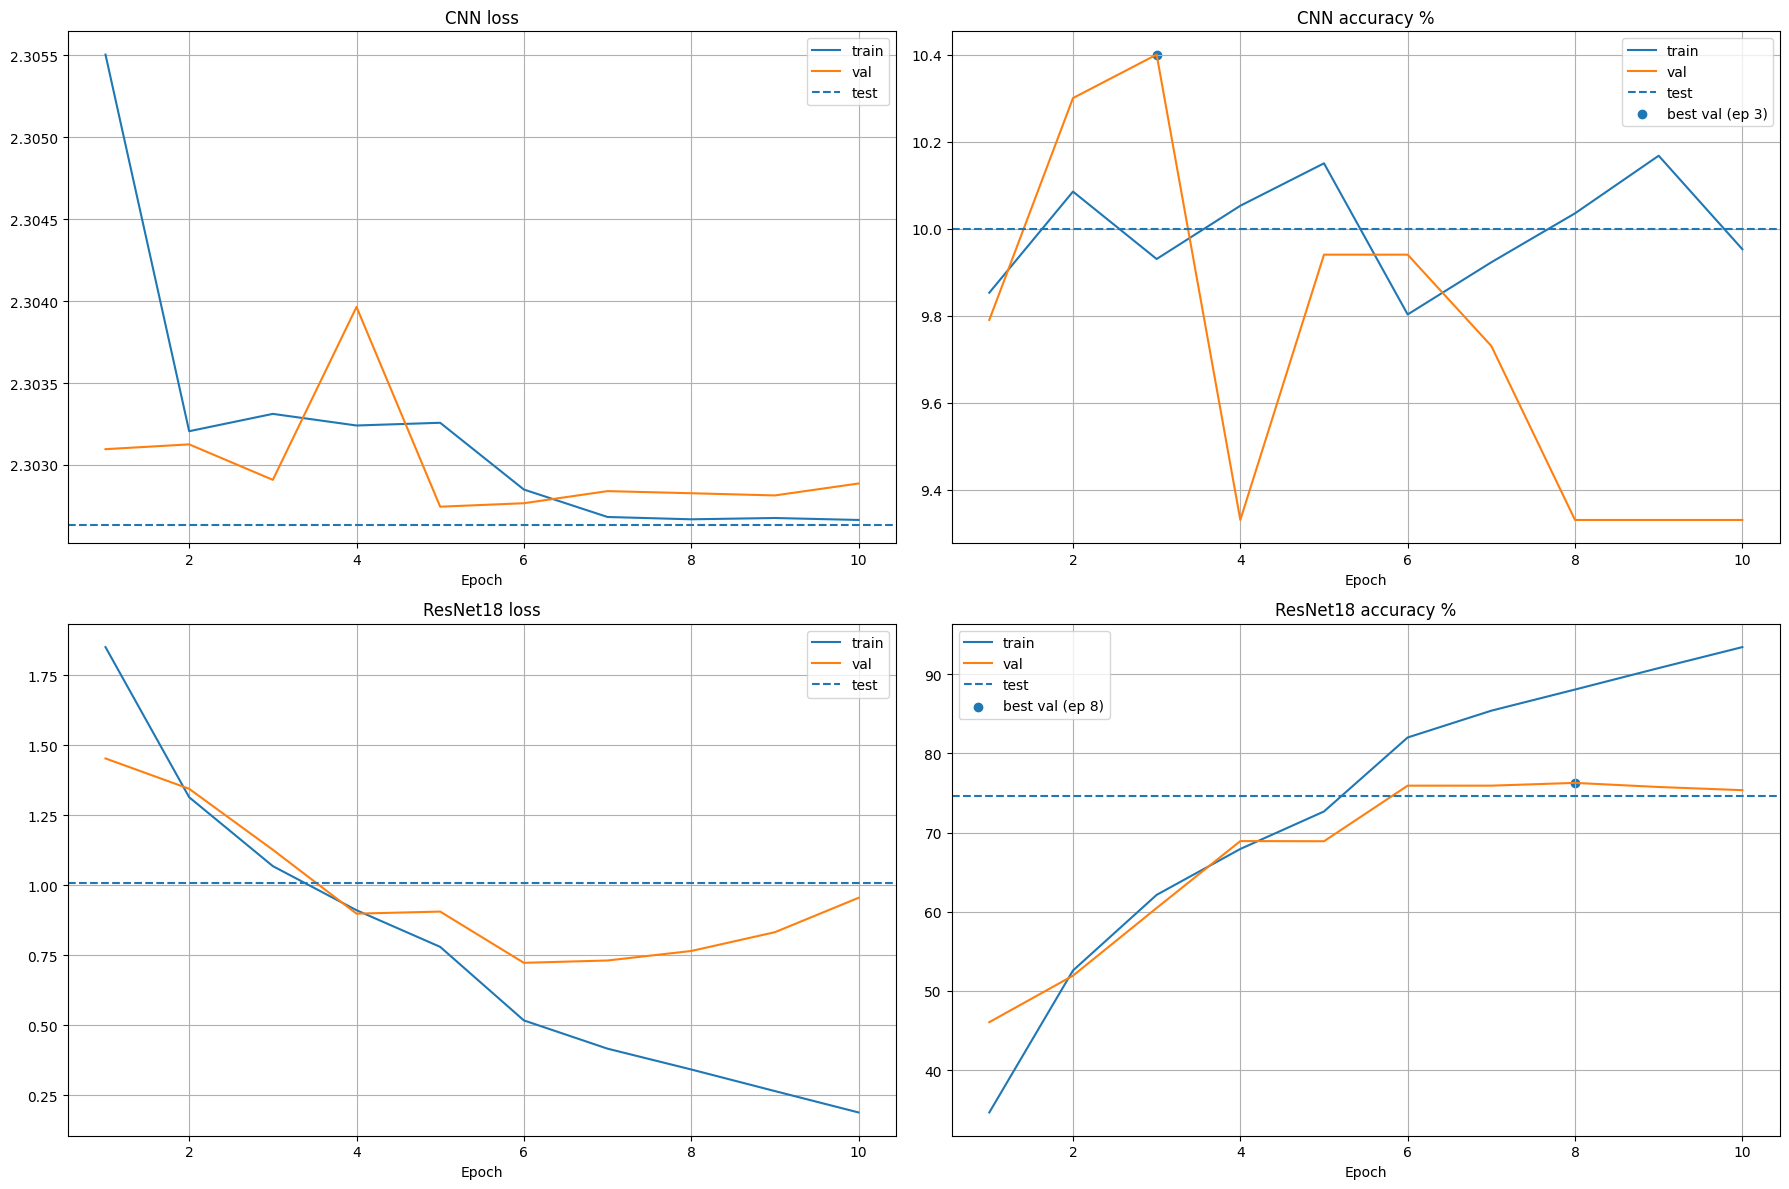

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].plot(epochs, history_cnn['train_loss'], label='train')
axes[0, 0].plot(epochs, history_cnn['val_loss'], label='val')
axes[0, 0].axhline(history_cnn['test_loss'], linestyle='--', linewidth=1.5, label='test')
axes[0, 0].set_title('CNN loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].grid(True)
axes[0, 0].legend()

axes[0, 1].plot(epochs, history_cnn['train_acc'], label='train')
axes[0, 1].plot(epochs, history_cnn['val_acc'], label='val')
axes[0, 1].axhline(history_cnn['test_acc'], linestyle='--', linewidth=1.5, label='test')
axes[0, 1].scatter([best_cnn_epoch], [best_cnn_val_acc], label=f'best val (ep {best_cnn_epoch})', marker='o')
axes[0, 1].set_title('CNN accuracy %')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].grid(True)
axes[0, 1].legend()

axes[1, 0].plot(epochs, history_resnet['train_loss'], label='train')
axes[1, 0].plot(epochs, history_resnet['val_loss'], label='val')
axes[1, 0].axhline(history_resnet['test_loss'], linestyle='--', linewidth=1.5, label='test')
axes[1, 0].set_title('ResNet18 loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].grid(True)
axes[1, 0].legend()

axes[1, 1].plot(epochs, history_resnet['train_acc'], label='train')
axes[1, 1].plot(epochs, history_resnet['val_acc'], label='val')
axes[1, 1].axhline(history_resnet['test_acc'], linestyle='--', linewidth=1.5, label='test')
axes[1, 1].scatter([best_resnet_epoch], [best_resnet_val_acc], label=f'best val (ep {best_resnet_epoch})', marker='o')
axes[1, 1].set_title('ResNet18 accuracy %')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Вывод
diff_test = history_resnet['test_acc'] - history_cnn['test_acc']
print('--- Итоги ---')
print(f"CNN:    best val acc = {best_cnn_val_acc:.2f}% (epoch {best_cnn_epoch}), test acc = {history_cnn['test_acc']:.2f}%")
print(f"ResNet: best val acc = {best_resnet_val_acc:.2f}% (epoch {best_resnet_epoch}), test acc = {history_resnet['test_acc']:.2f}%")
print(f"Разница по test acc (ResNet - CNN) = {diff_test:.2f} п.п.")

--- Итоги ---
CNN:    best val acc = 10.40% (epoch 3), test acc = 10.00%
ResNet: best val acc = 76.27% (epoch 8), test acc = 74.59%
Разница по test acc (ResNet - CNN) = 64.59 п.п.


Вывод: ResNet18 показывает лучшую обобщающую способность на CIFAR-10 (по test accuracy).